# HyperSense — External Transportability

## Ghana → Nigeria

### Objective

Evaluate how well the existing HyperSense v1.1 model generalizes to an independent Nigerian clinical cohort from the REMAH study, **without retraining or modifying the model using Nigerian data**.

### Research Question

> **Can the Ghana-derived HyperSense v1.1 model generalize to Nigerian adults without retraining?**

### Existing Model

HyperSense v1.1 is an XGBoost model developed using Ghana DHS 2014 with six predictors:

- Age
- Sex
- Residence
- Educational level
- Tobacco use
- BMI

### External Dataset

REMAH provides Nigerian clinical and behavioural data, including five clinic BP readings, anthropometry, tobacco use, pulse rate and laboratory measurements.

Only variables genuinely comparable with the v1.1 predictors will be used for transportability evaluation.

| HyperSense v1.1 | REMAH |
|---|---|
| `age` | `AGE` |
| `gender` | `SEX` |
| `residence` | `SITE` |
| `educational_level` | `EDU_QUA` |
| `tobacco_use` | `SMK_C` / `SMKL` |
| `bmi` | derived from `HT` and `WT` |

### Outcome

Hypertension will use the measurement-only definition:

> **Mean SBP ≥140 mmHg and/or mean DBP ≥90 mmHg.**

Mean BP will be derived from the five clinic BP readings. `HTN_DR` (Hypertensive Drug Therapy) will not be included in the primary transportability outcome because an equivalent treatment variable was unavailable in the DHS data with which the Ghanaian model was built.

### Evaluation

Primary evaluation will include:

- ROC-AUC
- Sensitivity and specificity
- PPV and NPV
- Calibration intercept and slope
- Brier score
- Calibration plot

The original v1.1 decision threshold will be evaluated without re-optimizing it on REMAH.

### Workflow

- [ ] Load and inspect REMAH
- [ ] Verify data quality and coding
- [ ] Construct the transportability outcome
- [ ] Derive BMI
- [ ] Harmonize the six predictors
- [ ] Verify compatibility with the v1.1 model
- [ ] Apply the existing v1.1 model
- [ ] Evaluate discrimination
- [ ] Evaluate calibration
- [ ] Age-Restricted Subgroup Analysis
- [ ] Summarize transportability findings
- [ ] Document limitations and implications

> KEY PRICNIPLE: **Validate first. Adapt second.**

In [276]:
# IMPORT REQUIRED LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Machine learning / evaluation
import sklearn
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

# Calibration model for estimating calibration intercept and slope
from sklearn.linear_model import LogisticRegression

# Model & loading
import xgboost as xgb
import joblib

# File and path management
from pathlib import Path

In [277]:
# Record package versions used for future reproducibility

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:  {xgb.__version__}")

pandas:   2.3.3
numpy:    2.4.0
scikit-learn: 1.8.0
xgboost:  3.3.0


### 1. Load & Inspect the Dataset Characteristics

In [278]:
remah = pd.read_excel("../data/REMAH/remah-1.xlsx")

print(f"Shape: {remah.shape}")
remah.head()

Shape: (4187, 76)


,S_NO,PIN,SEX,EST_AGE,DOB,AGE,SITE,EDU_QUA,M_STATUS,W_STATUS,SMK_C,SMK_D,SMK_D1,SMK_D2,M_CGRT,HR_CGRT,PIPE,CIGAR,SMK_OTHERS,SMK_P,SMK_P1,SMK_P2,SMKL,SMKL_MO,SMKL_NO,SMKL_CHEW,SMKL_OTHERS,SMK_PA_H,SMK_PA_WO,DRK,DRK_12,DRK12_FREQ,DRK_30,WRK_VI,WRK_VI_D,WRK_VI_T,WRK_MI,WRK_MI_D,WRK_MI_T,PA_W,PA_W_D,PA_W_T,SPRT_VI,SPRT_VI_D,SPRT_VI_T,SPRT_MI,SPRT_MI_D,SPRT_MI_T,HTN,HTN_DR,DM_M,DM,DM_INS,DM_OHA,CSBP1,CDBP1,CSBP2,CDBP2,CSBP3,CDBP3,CSBP4,CDBP4,CSBP5,CDBP5,PR,HT,WT,WC,HC,BLD_GLU,NA_URINE,HDL_CHOL,LDL_CHOL,TAG,TO_CHOL,K_URINE
0,1,10011001,1,78.000,1939-06-01,77.877,1,2.000,5.000,7.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,1.000,NaN,5.000,NaN,NaN,2.000,77.000,1.000,1.000,4.000,1.000,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,128.000,70.000,128.000,68.000,118.000,64.000,120.000,70.000,120.000,60.000,81.000,177.000,59.000,78.000,85.000,116.000,NaN,NaN,NaN,NaN,NaN,NaN
1,2,11001002,1,NaN,1964-02-02,53.197,2,3.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,2.000,NaN,NaN,NaN,NaN,77.000,77.000,1.000,1.000,NaN,1.000,2.000,NaN,NaN,1.000,3.000,00:10:00,1.000,7.000,00:15:00,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,1.000,2.000,NaN,NaN,120.000,78.000,120.000,80.000,124.000,82.000,130.000,84.000,128.000,82.000,70.000,177.000,95.000,114.000,116.000,138.000,NaN,NaN,NaN,NaN,NaN,NaN
2,3,10035001,1,NaN,1955-01-01,62.288,1,4.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,30.000,32.000,2.000,NaN,NaN,NaN,NaN,4.000,77.000,1.000,1.000,3.000,1.000,1.000,6.000,08:00:00,2.000,NaN,NaN,1.000,7.000,02:15:00,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,2.000,NaN,NaN,NaN,120.000,68.000,122.000,78.000,120.000,80.000,120.000,70.000,120.000,78.000,60.000,168.000,55.000,83.000,78.000,80.000,NaN,NaN,NaN,NaN,NaN,NaN
3,4,10001011,1,67.000,1950-01-01,67.288,1,2.000,2.000,7.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,77.000,NaN,2.000,NaN,NaN,NaN,NaN,77.000,77.000,1.000,1.000,3.000,1.000,2.000,NaN,NaN,2.000,NaN,NaN,1.000,7.000,00:30:00,2.000,NaN,NaN,2.000,NaN,NaN,2.000,NaN,2.000,2.000,NaN,NaN,138.000,70.000,130.000,76.000,128.000,70.000,128.000,76.000,130.000,70.000,63.000,165.000,55.000,80.000,89.000,131.000,NaN,NaN,NaN,NaN,NaN,NaN
4,5,10001001,1,NaN,1982-07-10,34.734,1,5.000,2.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,33.000,1.000,2.000,NaN,NaN,NaN,NaN,2.000,2.000,1.000,1.000,3.000,1.000,2.000,NaN,NaN,2.000,NaN,NaN,1.000,7.000,00:20:00,2.000,NaN,NaN,1.000,1.000,01:00:00,2.000,NaN,1.000,2.000,NaN,NaN,142.000,84.000,138.000,86.000,136.000,86.000,134.000,82.000,138.000,78.000,70.000,189.500,105.000,104.000,115.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Dataset Characteristics

In [279]:
# Initial dataset inspection

print("Shape:", remah.shape)
print("\nColumns:")
print(remah.columns.tolist())

Shape: (4187, 76)

Columns:
['S_NO', 'PIN', 'SEX', 'EST_AGE', 'DOB', 'AGE', 'SITE', 'EDU_QUA', 'M_STATUS', 'W_STATUS', 'SMK_C', 'SMK_D', 'SMK_D1', 'SMK_D2', 'M_CGRT', 'HR_CGRT', 'PIPE', 'CIGAR', 'SMK_OTHERS', 'SMK_P', 'SMK_P1', 'SMK_P2', 'SMKL', 'SMKL_MO', 'SMKL_NO', 'SMKL_CHEW', 'SMKL_OTHERS', 'SMK_PA_H', 'SMK_PA_WO', 'DRK', 'DRK_12', 'DRK12_FREQ', 'DRK_30', 'WRK_VI', 'WRK_VI_D', 'WRK_VI_T', 'WRK_MI', 'WRK_MI_D', 'WRK_MI_T', 'PA_W', 'PA_W_D', 'PA_W_T', 'SPRT_VI', 'SPRT_VI_D', 'SPRT_VI_T', 'SPRT_MI', 'SPRT_MI_D', 'SPRT_MI_T', 'HTN', 'HTN_DR', 'DM_M', 'DM', 'DM_INS', 'DM_OHA', 'CSBP1', 'CDBP1', 'CSBP2', 'CDBP2', 'CSBP3', 'CDBP3', 'CSBP4', 'CDBP4', 'CSBP5', 'CDBP5', 'PR', 'HT', 'WT', 'WC', 'HC', 'BLD_GLU', 'NA_URINE', 'HDL_CHOL', 'LDL_CHOL', 'TAG', 'TO_CHOL', 'K_URINE']


In [280]:
# Check for Variables with Missing values?

missing_summary = (
    remah.isna()
    .sum()
    .to_frame("Missing")
    .assign(
        Missing_pct=lambda x: (x["Missing"] / len(remah) * 100).round(2)
    )
    .assign(
        Complete=lambda x: x["Missing"] == 0
    )
    .sort_values("Missing", ascending=False)
)
print("\nMissing values:")
display(missing_summary)


Missing values:


,Missing,Missing_pct,Complete
PIPE,4187,100.000,False
SMKL_CHEW,4182,99.880,False
SMKL_OTHERS,4180,99.830,False
SMK_OTHERS,4178,99.790,False
HR_CGRT,4174,99.690,False
SMKL_MO,4168,99.550,False
CIGAR,4160,99.360,False
SMKL_NO,4121,98.420,False
M_CGRT,4103,97.990,False
SMK_D2,4091,97.710,False


In [281]:
# Inspect the coding and frequency of key categorical variables
    
cat_variables = ["SEX", "SITE", "EDU_QUA", "SMK_C", "SMKL", "HTN", "HTN_DR"]

table = []

for var in cat_variables:
    counts = remah[var].value_counts(dropna=False).sort_index()
    
    for category, frequency in counts.items():
        table.append({
            "Variable": var,
            "Category": category,
            "Frequency": frequency
        })

freq_table = pd.DataFrame(table)

print("Categorical variables:")
display(freq_table)

Categorical variables:


,Variable,Category,Frequency
0,SEX,1.000,1814
1,SEX,2.000,2373
2,SITE,1.000,2171
3,SITE,2.000,2016
4,EDU_QUA,1.000,658
5,EDU_QUA,2.000,193
6,EDU_QUA,3.000,707
7,EDU_QUA,4.000,1158
8,EDU_QUA,5.000,1131
9,EDU_QUA,7.000,299


In [282]:
# Inspect ranges and potential anomalies in continuous variables

continuous_vars = [
    "AGE",
    "HT",
    "WT",
    "CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5",
    "CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5",
]

# Summarize distribution, missingness, and range
quality_summary = (
    remah[continuous_vars]
    .describe()
    .T
    .assign(
        missing=remah[continuous_vars].isna().sum(),
        missing_pct=(remah[continuous_vars].isna().mean() * 100).round(2)
    )
    .sort_values(by="missing", ascending=False)
)

print("Continuous variables:")
display(quality_summary)

Continuous variables:


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
WT,4163.000,65.348,14.779,30.000,55.000,63.000,74.000,136.000,24,0.570
HT,4164.000,163.419,8.793,131.000,157.000,163.000,169.125,195.000,23,0.550
CDBP5,4169.000,78.254,13.591,22.000,70.000,78.000,86.000,168.000,18,0.430
CSBP5,4171.000,125.562,23.337,64.000,110.000,122.000,138.000,254.000,16,0.380
CDBP1,4182.000,78.027,13.606,40.000,70.000,78.000,86.000,162.000,5,0.120
CSBP2,4183.000,126.546,23.869,64.000,110.000,122.000,140.000,252.000,4,0.100
CSBP1,4183.000,127.035,24.218,60.000,110.000,122.000,140.000,250.000,4,0.100
AGE,4183.000,43.835,16.298,14.510,30.660,41.959,55.142,98.792,4,0.100
CSBP4,4183.000,125.719,23.366,66.000,110.000,122.000,138.000,256.000,4,0.100
CDBP4,4183.000,78.238,13.561,40.000,70.000,76.000,86.000,168.000,4,0.100


### 2. Build Harmonized Features and Outcome

Construct the six v1.1 predictors using the predefined REMAH → Ghana mapping. Hypertension is defined using the measurement-only criterion used to train v1.1:
mean SBP ≥140 mmHg and/or mean DBP ≥90 mmHg. No REMAH treatment information (`HTN_DR`) is incorporated into the outcome.

In [283]:
# Define the five clinic BP measurements used to construct the outcome
sbp_cols = ["CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5"]
dbp_cols = ["CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5"]

# Calculate mean clinic SBP and DBP across the five readings
remah["mean_sbp"] = remah[sbp_cols].mean(axis=1, skipna=False)
remah["mean_dbp"] = remah[dbp_cols].mean(axis=1, skipna=False)

incomplete = remah[["mean_sbp", "mean_dbp"]].isna().any(axis=1)

remah["htn_status"] = np.where(
    incomplete,
    np.nan,
    ((remah["mean_sbp"] >= 140) | (remah["mean_dbp"] >= 90)).astype(float)
)

In [284]:
# Construct the six predictors using the locked REMAH → v1.1 mapping

harmonized = pd.DataFrame(index=remah.index)

# Age is retained at full precision during harmonization
harmonized["age"] = remah["AGE"]

# Sex: REMAH 1 = Male, 2 = Female → v1.1 1 = Male, 0 = Female
harmonized["gender"] = remah["SEX"].map({1: 1, 2: 0})

# Residence: REMAH 1 = Rural, 2 = Urban → v1.1 0 = Rural, 1 = Urban
harmonized["residence"] = remah["SITE"].map({1: 0, 2: 1})

# Education: map REMAH qualification categories to the v1.1 four-level scale
education_map = {
    1: 0,
    2: 1,
    3: 1,
    4: 2,
    5: 3,
    7: 3,
    88: np.nan,
}
harmonized["educational_level"] = remah["EDU_QUA"].map(education_map)

# Tobacco: current smoking OR smokeless tobacco; missing only when both are missing
smoking = remah["SMK_C"]
smokeless = remah["SMKL"]

harmonized["tobacco_use"] = np.where(
    smoking.isna() & smokeless.isna(),
    np.nan,
    ((smoking == 1) | (smokeless == 1)).astype(int)
)

# BMI: true-scale BMI calculated from height in cm and weight in kg
harmonized["bmi"] = remah["WT"] / (remah["HT"] / 100) ** 2

# Add the outcome to the harmonized analysis dataset
harmonized["htn_status"] = remah["htn_status"]

In [285]:
# View new harmonized dataframe
display(harmonized.head(10))

,age,gender,residence,educational_level,tobacco_use,bmi,htn_status
0,77.877,1,0,1.000,1.000,18.832,0.000
1,53.197,1,1,1.000,0.000,30.323,0.000
2,62.288,1,0,2.000,0.000,19.487,0.000
3,67.288,1,0,1.000,0.000,20.202,0.000
4,34.734,1,0,3.000,0.000,29.240,0.000
5,79.159,1,0,1.000,1.000,27.340,0.000
6,31.712,1,1,3.000,0.000,19.841,0.000
7,75.293,1,0,2.000,0.000,21.936,1.000
8,38.534,1,1,3.000,0.000,25.181,0.000
9,30.732,1,1,3.000,0.000,20.658,0.000


In [286]:
# Number of observations with missing htn_status variable
print(harmonized['htn_status'].isna().sum())

20


In [287]:
harmonized["htn_status"].value_counts(dropna=False)

htn_status
0.000    2987
1.000    1180
NaN        20
Name: count, dtype: int64

In [288]:
# Restrict the analysis to complete cases required for prediction and outcome evaluation

model_features = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi",
]

analysis_cols = model_features + ["htn_status"]

transportability = harmonized.dropna(subset=analysis_cols).copy()

print(f"Complete-case sample: n = {len(transportability):,}")
print(
    f"Hypertension prevalence: "
    f"{transportability['htn_status'].mean() * 100:.1f}%"
)

Complete-case sample: n = 4,089
Hypertension prevalence: 28.2%


In [289]:
# Inspect the final harmonized predictors before model application

display(transportability[model_features + ["htn_status"]].head())
display(transportability[model_features].describe().T)

,age,gender,residence,educational_level,tobacco_use,bmi,htn_status
0,77.877,1,0,1.000,1.000,18.832,0.000
1,53.197,1,1,1.000,0.000,30.323,0.000
2,62.288,1,0,2.000,0.000,19.487,0.000
3,67.288,1,0,1.000,0.000,20.202,0.000
4,34.734,1,0,3.000,0.000,29.240,0.000


,count,mean,std,min,25%,50%,75%,max
age,4089.000,43.739,16.239,14.510,30.622,41.693,55.079,98.792
gender,4089.000,0.434,0.496,0.000,0.000,0.000,1.000,1.000
residence,4089.000,0.482,0.500,0.000,0.000,0.000,1.000,1.000
educational_level,4089.000,1.813,1.078,0.000,1.000,2.000,3.000,3.000
tobacco_use,4089.000,0.059,0.236,0.000,0.000,0.000,0.000,1.000
bmi,4089.000,24.418,5.092,11.668,20.812,23.422,27.131,56.296


###  3. Apply HyperSense v1.1 to REMAH

The pretrained Ghana-derived model is applied directly to the harmonized Nigerian cohort. No retraining, refitting, recalibration, or threshold optimization is performed. Age is rounded to the nearest whole year only at this final model-input step.

In [290]:
# Load the previously trained HyperSense v1.1 artifacts

model_path = "../models/hypersense_xgb_v11.pkl"
threshold_path = "../models/hypersense_threshold_v11.pkl"

hypersense_v11 = joblib.load(model_path)
deployment_threshold = float(joblib.load(threshold_path))

print("v1.1 model loaded")
print(f"Deployment threshold: {deployment_threshold:.2f}")

v1.1 model loaded
Deployment threshold: 0.50


In [291]:
# Create the exact model input representation used for v1.1 prediction

X_remah = transportability[model_features].copy()

# Match the integer-year age representation used during v1.1 training
X_remah["age"] = X_remah["age"].round().astype(int)

y_remah = transportability["htn_status"].copy()

# Generate predicted probabilities from the unchanged v1.1 model
y_prob = hypersense_v11.predict_proba(X_remah)[:, 1]

# Apply the predefined v1.1 deployment threshold
y_pred = (y_prob >= deployment_threshold).astype(int)

print(f"Predictions generated for n = {len(y_prob):,} participants")

Predictions generated for n = 4,089 participants


### 4. Discrimination and Classification Performance

Evaluate the unchanged v1.1 model using ROC-AUC and threshold-based classification metrics at the predefined 0.50 threshold.

In [292]:
# Calculate discrimination and threshold-based classification metrics

auc = roc_auc_score(y_remah, y_prob)

tn, fp, fn, tp = confusion_matrix(
    y_remah,
    y_pred,
    labels=[0, 1]
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

performance = pd.DataFrame({
    "Metric": [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
    ],
    "REMAH": [
        auc,
        sensitivity,
        specificity,
        ppv,
        npv,
    ],
})

display(performance)

,Metric,REMAH
0,AUC,0.747
1,Sensitivity,0.941
2,Specificity,0.407
3,PPV,0.383
4,NPV,0.946


In [293]:
# Display the confusion matrix at the fixed 0.50 threshold

cm = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Observed 0", "Observed 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm)

,Predicted 0,Predicted 1
Observed 0,1194,1743
Observed 1,68,1084


### 5. Calibration

Assess agreement between predicted probabilities and observed hypertension status using:

- Calibration intercept
- Calibration slope
- Brier score
- Calibration plot

In [294]:
# Estimate calibration intercept and slope from the model's predicted probabilities

eps = 1e-15
y_prob_clipped = np.clip(y_prob, eps, 1 - eps)

logit_pred = np.log(
    y_prob_clipped / (1 - y_prob_clipped)
).reshape(-1, 1)

calibration_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=1000
)

calibration_model.fit(logit_pred, y_remah)

calibration_intercept = calibration_model.intercept_[0]
calibration_slope = calibration_model.coef_[0, 0]

brier = brier_score_loss(y_remah, y_prob)

calibration_results = pd.DataFrame({
    "Metric": [
        "Calibration intercept",
        "Calibration slope",
        "Brier score",
    ],
    "REMAH": [
        calibration_intercept,
        calibration_slope,
        brier,
    ],
})

display(calibration_results)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,REMAH
0,Calibration intercept,-1.798
1,Calibration slope,1.276
2,Brier score,0.276


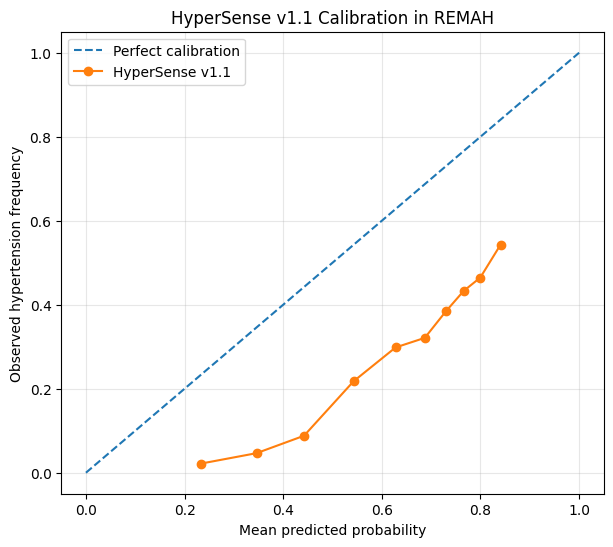

In [295]:
# Plot predicted probability against observed hypertension frequency

prob_true, prob_pred = calibration_curve(
    y_remah,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="HyperSense v1.1"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed hypertension frequency")
plt.title("HyperSense v1.1 Calibration in REMAH")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6. Age-Restricted Subgroup Analysis

Repeat discrimination and calibration among participants aged ≤59 years. This evaluates performance within the age range represented in the Ghana v1.1 development data, while the primary analysis retains the full REMAH cohort.

In [296]:
# Define a reusable function for discrimination and calibration evaluation

def evaluate_transportability(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    prob_clipped = np.clip(y_prob, 1e-15, 1 - 1e-15)
    logit_pred = np.log(
        prob_clipped / (1 - prob_clipped)
    ).reshape(-1, 1)

    calibration_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=1000
    )

    calibration_model.fit(logit_pred, y_true)

    return {
        "n": len(y_true),
        "prevalence": y_true.mean(),
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Calibration intercept": calibration_model.intercept_[0],
        "Calibration slope": calibration_model.coef_[0, 0],
        "Brier score": brier_score_loss(y_true, y_prob),
    }

In [297]:
# Evaluate the full REMAH cohort and the age-restricted subgroup

full_results = evaluate_transportability(
    y_remah,
    y_prob,
    deployment_threshold
)

age_restricted_mask = transportability["age"] <= 59

restricted_results = evaluate_transportability(
    y_remah.loc[age_restricted_mask],
    y_prob[age_restricted_mask],
    deployment_threshold
)

subgroup_results = pd.DataFrame(
    [full_results, restricted_results],
    index=["Full REMAH", "Age ≤59"]
).T

display(subgroup_results)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Full REMAH,Age ≤59
n,4089.000,3294.000
prevalence,0.282,0.226
AUC,0.747,0.779
Sensitivity,0.941,0.928
Specificity,0.407,0.460
PPV,0.383,0.335
NPV,0.946,0.956
Calibration intercept,-1.798,-2.118
Calibration slope,1.276,1.379
Brier score,0.276,0.273


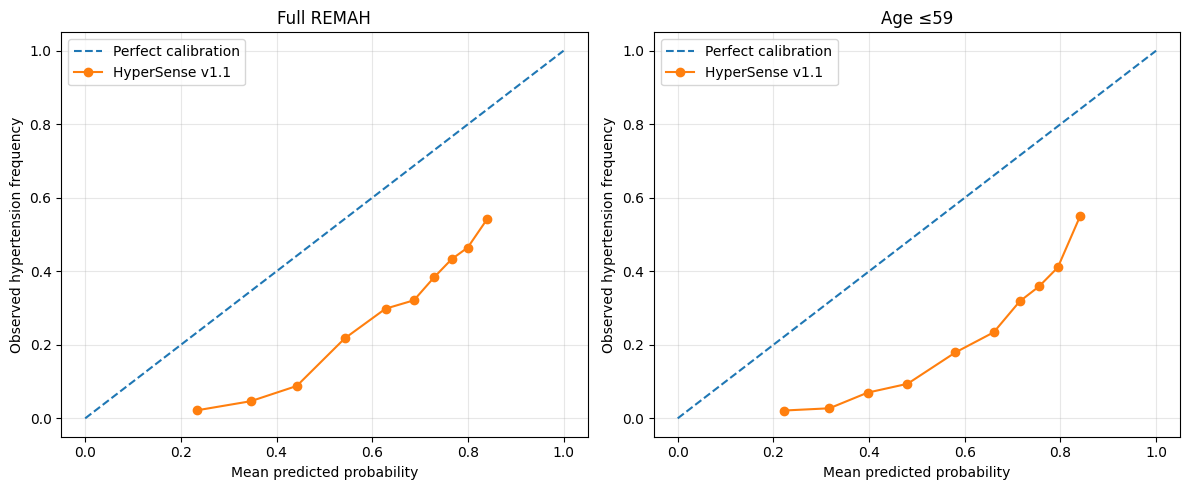

In [298]:
# Plot calibration for the full and age-restricted REMAH cohorts

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mask, title in [
    (axes[0], np.ones(len(y_remah), dtype=bool), "Full REMAH"),
    (axes[1], age_restricted_mask.to_numpy(), "Age ≤59"),
]:
    prob_true, prob_pred = calibration_curve(
        y_remah[mask],
        y_prob[mask],
        n_bins=10,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.plot(
        prob_pred,
        prob_true,
        marker="o",
        label="HyperSense v1.1"
    )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed hypertension frequency")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Final Comparison With Original Ghana v1.1 Performance

Compare external REMAH performance with the previously reported Ghana v1.1 test-set performance. The Ghana reference values are retained as originally reported and are not recalculated using REMAH.

In [299]:
# Build the final comparison table against the previously reported Ghana v1.1 results

comparison = pd.DataFrame({
    "Metric": [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Calibration intercept",
        "Calibration slope",
        "Brier score",
    ],
    "Ghana v1.1 (reported)": [ # Values are from v1.1 test-set evaluation, 07_bmi_model_ready.ipynb, cell 47
        0.7916,
        0.8232, 
        0.5764, 
        0.2022, # PPV = Precision
        0.9615, # Calculated based on confusion matrix values
        "Not reported",
        "Not reported",
        0.2355,
    ],
    "REMAH (full cohort)": [
        full_results["AUC"],
        full_results["Sensitivity"],
        full_results["Specificity"],
        full_results["PPV"],
        full_results["NPV"],
        full_results["Calibration intercept"],
        full_results["Calibration slope"],
        full_results["Brier score"],
    ],
    "REMAH (age ≤59)": [
        restricted_results["AUC"],
        restricted_results["Sensitivity"],
        restricted_results["Specificity"],
        restricted_results["PPV"],
        restricted_results["NPV"],
        restricted_results["Calibration intercept"],
        restricted_results["Calibration slope"],
        restricted_results["Brier score"],
    ],
})

display(comparison)

,Metric,Ghana v1.1 (reported),REMAH (full cohort),REMAH (age ≤59)
0,AUC,0.792,0.747,0.779
1,Sensitivity,0.823,0.941,0.928
2,Specificity,0.576,0.407,0.460
3,PPV,0.202,0.383,0.335
4,NPV,0.962,0.946,0.956
5,Calibration intercept,Not reported,-1.798,-2.118
6,Calibration slope,Not reported,1.276,1.379
7,Brier score,0.235,0.276,0.273


In [300]:
# Export final transportability results for reproducibility

from pathlib import Path

# Store transportability outputs in a dedicated subfolder
output_dir = Path("../outputs/transportability")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the final subgroup results
subgroup_results.to_csv(
    output_dir / "subgroup_results.csv",
    index=False
)

# Save the comparison with the original Ghana v1.1 results
comparison.to_csv(
    output_dir / "comparison_with_v11.csv",
    index=False
)

print(f"Results exported to: {output_dir}")

Results exported to: ..\outputs\transportability


### Conclusion (of Stage 1)

The Ghana-derived HyperSense v1.1 model was externally evaluated in the Nigerian REMAH cohort without retraining, refitting, recalibration, or changing the decision threshold.

Overall, the model retained reasonable discrimination, with AUC falling from *0.792* in Ghana to *0.747* in the full REMAH cohort. When restricted to participants aged ≤59, which matches the age range of the original Ghana training data, the AUC improved to *0.779*. This suggests that part of the drop in performance may be related to applying the model to participants outside the age range it was trained on.

The bigger issue was the balance between sensitivity and specificity. Sensitivity increased from *0.823* in Ghana to *0.941* in REMAH, but specificity fell from *0.576* to *0.407*. The calibration results also showed that the model systematically overpredicted hypertension risk in REMAH. This is particularly interesting because REMAH actually had a much higher hypertension prevalence than the Ghana training data (28.2% vs. 11.5%), so prevalence difference alone would not explain this pattern.

A likely explanation is the ``scale_pos_weight`` used during v1.1 training to address the low prevalence of hypertension in Ghana. That correction made sense in the original setting, but when carried unchanged into a population where hypertension is much more common, it may push the model towards predicting too many positive cases.

These findings provide the baseline external transportability of HyperSense v1.1 and motivate Stage 2, where Nigerian data will be incorporated through regional adaptation. This will include reconsidering both the class-imbalance strategy and the decision threshold rather than carrying the Ghana-specific settings forward unchanged.